# Piper Perturbation Demo
This script demonstrates how to load an AgileX Piper trajectory, apply perturbations
using the `a2l-pr` package, and visualize the results.

In [1]:
import os
import sys

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.piper import PiperAdapter
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.recovery.generator import RecoveryCodeGenerator, recovery_to_json
from a2l_pr.utils.visualization import visualize_trajectory_comparison, visualize_trajectory_comparison_3d
from a2l_pr.config.config import ConfigManager

## Configuration and Loading

In [2]:
TASK="pick_bag_joe"
EPISODE = "episode_001"

# Load configuration
config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)

# Path to the Piper actions.csv file (Update this path if necessary)
piper_csv_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "agilex_data_collection", TASK, EPISODE, "actions.csv"
))

if not os.path.exists(piper_csv_path):
    print(f"File not found: {piper_csv_path}")
    print("Please update the path to a valid Piper actions.csv file.")
else:
    # Initialize the Piper adapter and load the trajectory
    adapter = PiperAdapter()
    trajectory = adapter.load(piper_csv_path)

    # Inject dataset defaults from config
    dataset_defaults = config_mgr.get_dataset_defaults(trajectory['metadata']['dataset_type'])
    trajectory['metadata'].update(dataset_defaults)
    trajectory['metadata'].update(config_mgr.get_perturbation_config())

    print(f"Loaded Piper trajectory with {len(trajectory['actions'])} steps.")

Loaded Piper trajectory with 493 steps.


## Apply Perturbation

Applying Premature Close Perturbation...
Success! Perturbation applied: PREMATURE_CLOSE
Failure Mode: Closing before object alignment, causing failed grasp.


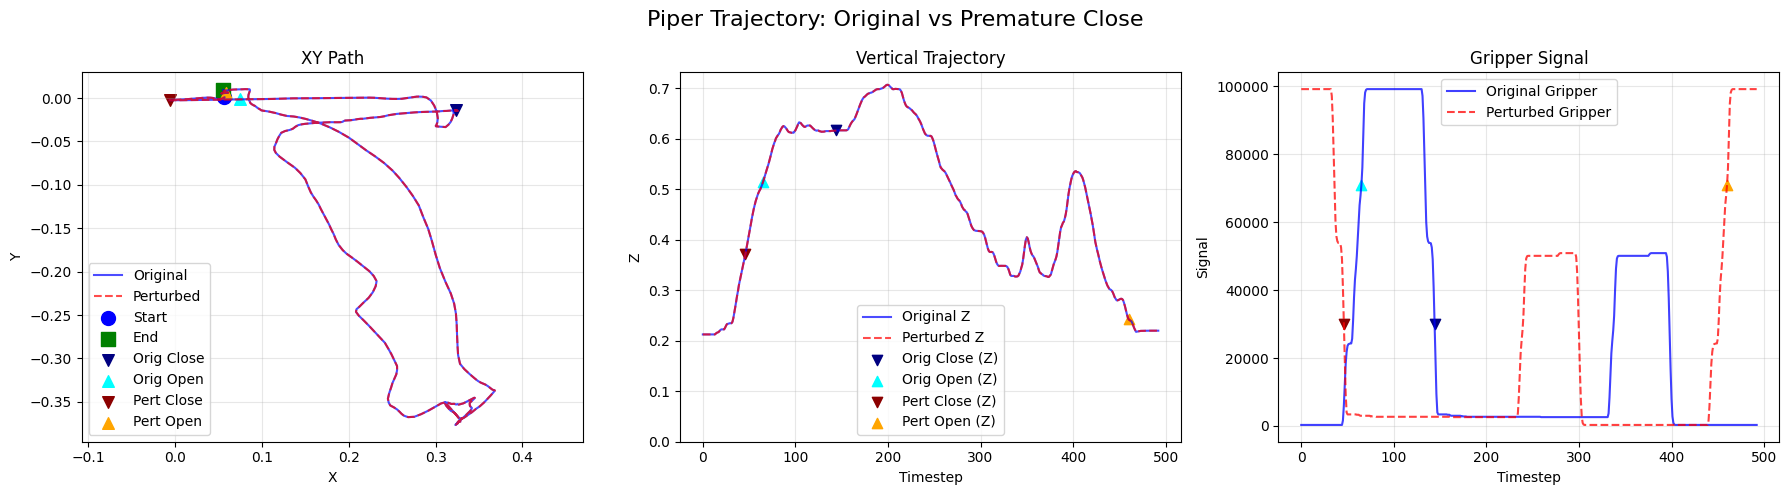

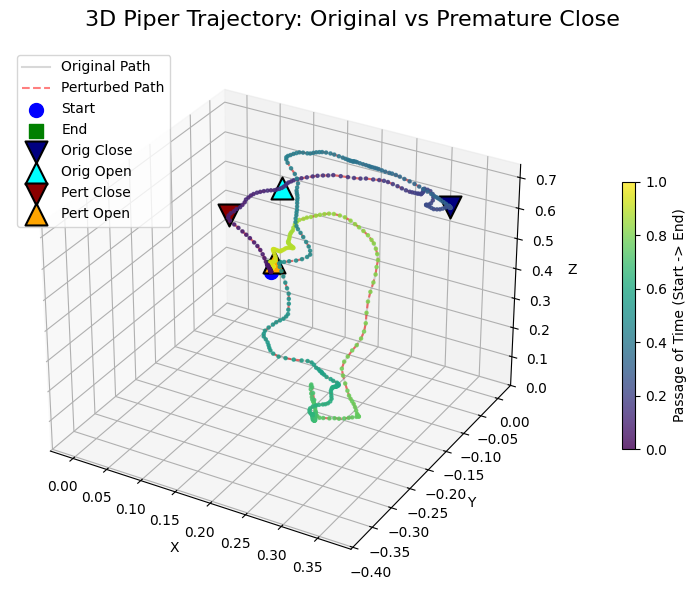

In [3]:
if os.path.exists(piper_csv_path):
    # Initialize generator
    generator = PerturbationGenerator()

    # Apply a Premature Close perturbation
    print("Applying Premature Close Perturbation...")
    result = generator.apply_perturbation(
        trajectory, 
        PerturbationType.PREMATURE_CLOSE, 
        severity=0.6,
        seed=42
    )

    if result is not None:
        print(f"Success! Perturbation applied: {result.perturbation_type.name}")
        print(f"Failure Mode: {result.theoretical_failure_mode}")
        
        # Visualize the comparison
        visualize_trajectory_comparison(
            trajectory, 
            result.perturbed_trajectory, 
            title="Piper Trajectory: Original vs Premature Close"
        )
        visualize_trajectory_comparison_3d(
            trajectory, 
            result.perturbed_trajectory, 
            title="3D Piper Trajectory: Original vs Premature Close"
        )
    else:
        print("Perturbation not applicable for this trajectory.")

## Generate Recovery FSM

In [4]:
if os.path.exists(piper_csv_path) and result is not None:
    print("\nGenerating Recovery FSM DSL...")
    recovery_code = RecoveryCodeGenerator.generate_recovery_code(result)
    
    # Pretty print the JSON
    print(recovery_to_json(recovery_code))


Generating Recovery FSM DSL...
{
  "dsl_version": "deterministic_recovery_fsm_v1",
  "execution_model": "sequential_fsm",
  "severity_hint": "moderate",
  "parameters": {
    "perturbation_type": "premature_gripper_close",
    "shift_steps": -98,
    "inferred_close_step": 144,
    "xy_tolerance_m": 0.066,
    "max_align_steps": 26
  },
  "robot_interface_contract": {
    "requires_live_ee_pose": true,
    "requires_gripper_state_if_used": true,
    "requires_metric_evaluator": true,
    "history_context_required": false
  },
  "program": [
    {
      "id": "S1",
      "call": "set_gripper(value=\"open\")",
      "termination": {
        "logic": "ANY",
        "predicates": [
          {
            "lhs": "gripper_opened",
            "cmp": ">=",
            "rhs": 0.9
          }
        ],
        "max_steps": 5
      },
      "next_on_success": "S2",
      "next_on_timeout": "S2"
    },
    {
      "id": "S2",
      "call": "align_end_effector_to_object(mode=\"centroid_or_grasp

## Apply Lateral Drift Perturbation


Applying Lateral Drift Perturbation...


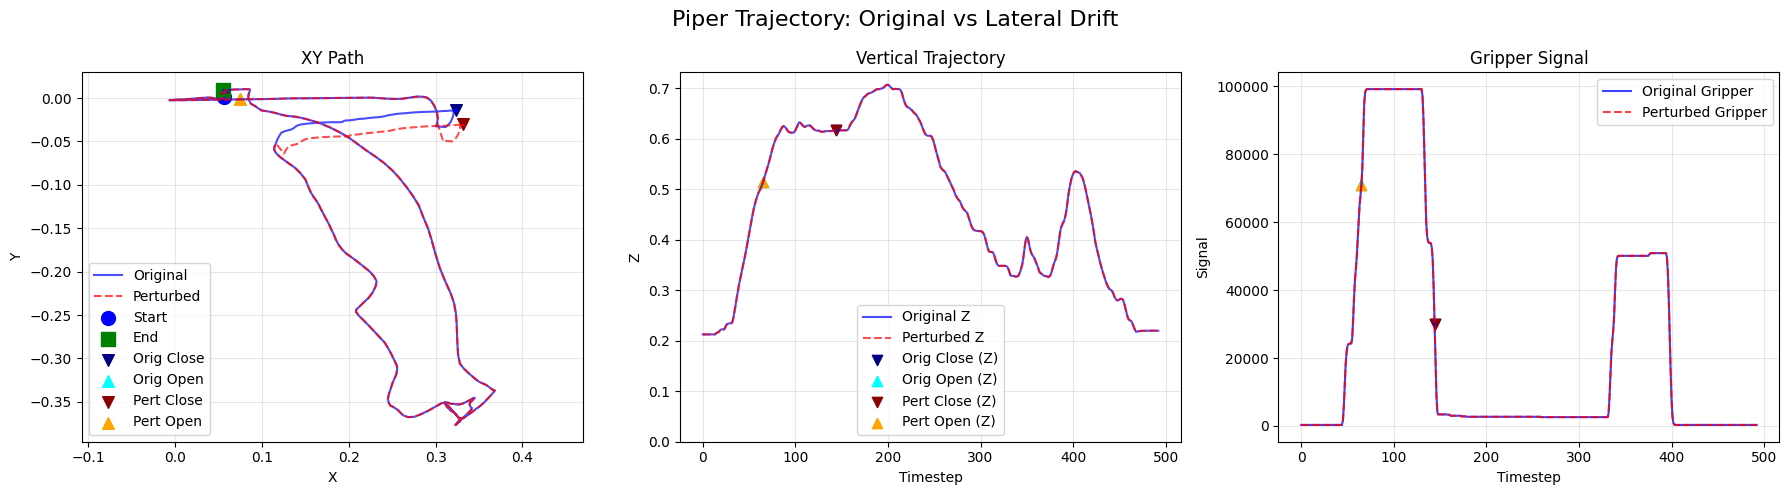

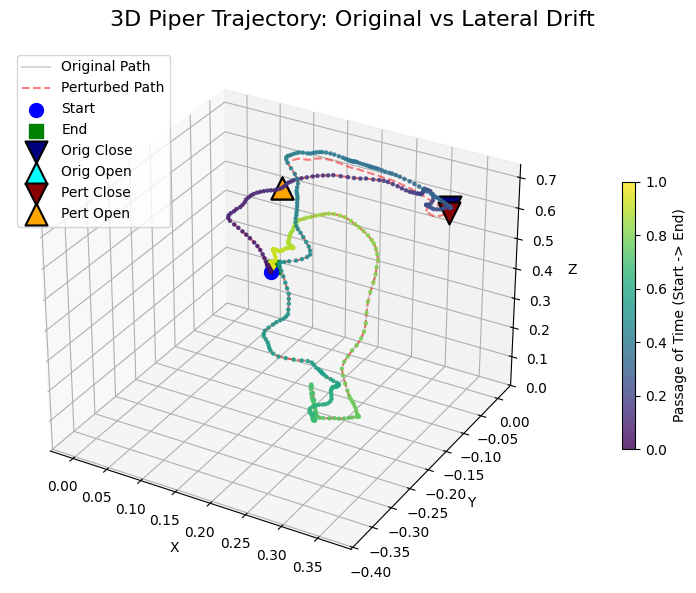

In [5]:
if os.path.exists(piper_csv_path):
    print("\nApplying Lateral Drift Perturbation...")
    result_drift = generator.apply_perturbation(
        trajectory, 
        PerturbationType.LATERAL_DRIFT, 
        severity=0.8,
        seed=100
    )

    if result_drift is not None:
        visualize_trajectory_comparison(
            trajectory, 
            result_drift.perturbed_trajectory, 
            title="Piper Trajectory: Original vs Lateral Drift"
        )
        visualize_trajectory_comparison_3d(
            trajectory, 
            result_drift.perturbed_trajectory, 
            title="3D Piper Trajectory: Original vs Lateral Drift"
        )

## Generate Video of Original Trajectory

In [6]:
import subprocess
from IPython.display import Video, display
import os

video_name = f"piper_{EPISODE}.mp4"
fps = 30

zed_dir = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "agilex_data_collection", TASK, EPISODE, "zed_color"
))

cmd = [
    "ffmpeg",
    "-y",
    "-framerate", str(fps),
    "-pattern_type", "glob",
    "-i", f"{zed_dir}/*.png",
    "-c:v", "libx264",
    "-preset", "slow",      # Slower compression = better efficiency
    "-crf", "28",          # Higher CRF = smaller file size
    "-pix_fmt", "yuv420p", # Essential for browser compatibility
    "-vf", "scale=iw/2:-1", # OPTIONAL: Halves the resolution (huge size saver)
    video_name
]

if os.path.exists(zed_dir):
    print("\nGenerating video from zed images...")
    print("Running FFmpeg...")
    subprocess.run(cmd, check=True)
else:
    print(f"Directory {zed_dir} does not exist")

display(Video(video_name, embed=True))


Generating video from zed images...
Running FFmpeg...


ffmpeg version 7.1.1-1ubuntu1.3 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14 (Ubuntu 14.2.0-19ubuntu2)
  configuration: --prefix=/usr --extra-version=1ubuntu1.3 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-libmfx --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg -